# Import


In [1]:
import numpy as np
import random
import string
import tensorflow as tf
import keras
from tensorflow import keras
from keras import layers, Model, metrics
from keras.layers import Input, Embedding, Dense
from keras_nlp.layers import TransformerEncoder, TransformerDecoder
from keras.losses import sparse_categorical_crossentropy
from google.colab import drive




# 1. PROJECT SETUP AND DATA GENERATION

Mount the drive to save weights. The cell below has to be executed only if new weights need to be saved on drive

In [ ]:
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In the cell below the vocabulary is defined, consisting of operators, special tokens for the start and end of expression, and the letters used for mathematical operations.
Dictionaries are then defined to switch from tokens to IDs and vice versa: these dictionaries are used by functions that have this very task.

The number of training and test samples is defined. It is noted that given the complexity of the problem, the number of samples could also be lower to obtain good network performance.





In [11]:
# -------------------- Constants --------------------
OPERATORS = ['+', '-', '*', '/']
IDENTIFIERS = list('abcde')
SPECIAL_TOKENS = ['PAD', 'SOS', 'EOS']
SYMBOLS = ['(', ')', '+', '-', '*', '/']
VOCAB = SPECIAL_TOKENS + SYMBOLS + IDENTIFIERS + ['JUNK']

NUM_TRAIN = 10000
NUM_TEST = 1000

token_to_id = {tok: i for i, tok in enumerate(VOCAB)}
print(f"ids: {token_to_id}")

id_to_token = {i: tok for tok, i in token_to_id.items()}
print(f"token: {id_to_token}")

VOCAB_SIZE = len(VOCAB)

PAD_ID = token_to_id['PAD']
EOS_ID = token_to_id['EOS']
SOS_ID = token_to_id['SOS']

MAX_DEPTH = 3
# Formula for max length of a fully parenthesized expression
MAX_LEN = 4 * (2**MAX_DEPTH - 1) + 1

ids: {'PAD': 0, 'SOS': 1, 'EOS': 2, '(': 3, ')': 4, '+': 5, '-': 6, '*': 7, '/': 8, 'a': 9, 'b': 10, 'c': 11, 'd': 12, 'e': 13, 'JUNK': 14}
token: {0: 'PAD', 1: 'SOS', 2: 'EOS', 3: '(', 4: ')', 5: '+', 6: '-', 7: '*', 8: '/', 9: 'a', 10: 'b', 11: 'c', 12: 'd', 13: 'e', 14: 'JUNK'}


The dataset is generated using the "generate dataset" function, which calls another function, "infix_to_postfix". In this way, the infix expressions and the corresponding postfix expressions are created.

The "shift_right" function will be used to implement teacher forcing.

In [12]:


# -------------------- Expression Generation ---------------------------------------------------------------------------------------------------------------
def generate_infix_expression(max_depth):
    if max_depth == 0:
        return random.choice(IDENTIFIERS)
    elif random.random() < 0.5:
        return generate_infix_expression(max_depth - 1)
    else:
        left = generate_infix_expression(max_depth - 1)
        right = generate_infix_expression(max_depth - 1)
        op = random.choice(OPERATORS)
        return f'({left} {op} {right})'

#takes the infix string and turns it into a list of tokens
def tokenize(expr):
    # Added spaces around operators and parentheses for easier splitting
    expr = expr.replace('(', ' ( ')
    expr = expr.replace(')', ' ) ')
    return [c for c in expr.split() if c in token_to_id]


def infix_to_postfix(tokens):
    precedence = {'+': 1, '-': 1, '*': 2, '/': 2}
    output, stack = [], []
    for token in tokens:
        if token in IDENTIFIERS:
            output.append(token)
        elif token in OPERATORS:
            while stack and stack[-1] in OPERATORS and precedence.get(stack[-1], 0) >= precedence.get(token, 0):
                output.append(stack.pop())
            stack.append(token)
        elif token == '(':
            stack.append(token)
        elif token == ')':
            while stack and stack[-1] != '(':
                output.append(stack.pop())
            if stack and stack[-1] == '(':
                stack.pop()
    while stack:
        output.append(stack.pop())
    return output

#takes the tokens and returns a list of ids with EOS_ID at the end of the sentence
def encode(tokens, max_len=MAX_LEN):
    ids = [token_to_id[t] for t in tokens] + [EOS_ID]

    # Handles both padding and truncation
    if len(ids) > max_len:
        # Truncate the sequence if it is too long
        return ids[:max_len]
    else:
        # Pad the sequence if it is too short
        return ids + [PAD_ID] * (max_len - len(ids))

#takes id and returns token
def decode_sequence(token_ids, id_to_token_map):
    tokens = []
    for token_id in token_ids:
        token = id_to_token_map.get(token_id, '?')
        if token == id_to_token_map[EOS_ID]:
            break
        if token != id_to_token_map[PAD_ID]:
            tokens.append(token)
    return "".join(tokens)


def generate_dataset(n, max_depth=MAX_DEPTH):
    X, Y = [], []
    seen = set()
    while len(X) < n:
        expr = generate_infix_expression(max_depth)
        if expr in seen:
            continue
        seen.add(expr)

        infix_tokens = tokenize(expr)
        postfix_tokens = infix_to_postfix(infix_tokens)

        X.append(encode(infix_tokens))
        Y.append(encode(postfix_tokens))

    return np.array(X), np.array(Y)

# Used for teacher-forcing during training
def shift_right(seqs):

    # ensure seqs is a tensor
    seqs = tf.convert_to_tensor(seqs)

    # create a column of SOS_ID tokens with the same batch size and dtype
    batch_size = tf.shape(seqs)[0]
    sos_tokens = tf.fill([batch_size, 1], SOS_ID)
    sos_tokens = tf.cast(sos_tokens, dtype=seqs.dtype)

    # get the body of the sequence (all but the last token)
    body_tokens = seqs[:, :-1]

    # concatenate to form the new input: [SOS, token1, token2, ...]
    return tf.concat([sos_tokens, body_tokens], axis=1)

#generate the dataaset
print("Generating dataset...\n")
X_train, Y_train = generate_dataset(NUM_TRAIN)

X_val, Y_val = generate_dataset(NUM_TEST)
print(f"Example :{X_val[0]}\n")


print(f"Dataset created. Train samples: {len(X_train)}, Validation samples: {len(X_val)}")
print(f"Vocab size: {VOCAB_SIZE}, Max sequence length: {MAX_LEN}")

#see one sample
i = np.random.randint(len(X_train))
print("\n Sample after decodification: \n")
print("Infix (decoded tokens) :", decode_sequence(X_train[i], id_to_token))
print("Postfix (decoded tokens):", decode_sequence(Y_train[i], id_to_token))




Generating dataset...

Example :[ 3  3  3 13  5 11  4  5  3 12  6 11  4  4  6  3  9  6 12  4  4  2  0  0
  0  0  0  0  0]

Dataset created. Train samples: 10000, Validation samples: 1000
Vocab size: 15, Max sequence length: 29

 Sample after decodification: 

Infix (decoded tokens) : (((d/d)-(a+c))+c)
Postfix (decoded tokens): dd/ac+-c+


# 2. TRANSFORMER MODEL DEFINITION


## Definition of encoder and decoder

In this section encoder and decoder models are defined.

It is important in this case to not exceed the limit of 2 million parameters.
Hyperparameters define the number of trainable parameters of the model and in this case they are around 170.000. For this task, given the small size of the vocabulary, it could be possible to reduce further this number.

A custom embedding layer is created that implements token embedding and positional embedding. Token embedding is essential to "capture" the meaning of the tokens. Positional embedding adds information about the position of each token within the sequence, this is crucial for a transformer because otherwise the model would not be able to distinguish between two inputs with the same tokens but in different order, leading to problematic learning.

The encoder model is created by passing the embeddings as input.

The decoder model is created by passing the embeddings and the encoder output as input. A dense layer is then added, this allows to obtain as output a probability vector for each token in the dictionary.

In [13]:
#Hyperparameters
EMBEDDING_DIM = 64
NUM_HEADS = 8
INTERMEDIATE_DIM = 128
NUM_LAYERS = 2


# create a layer for embedding. Also positional embedding is implemented
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = layers.Embedding(input_dim=maxlen, output_dim=embed_dim)
        self.maxlen = maxlen
        self.embed_dim = embed_dim

    def call(self, x):
        maxlen = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        # sum token embedding to its position
        return self.token_emb(x) + self.pos_emb(positions)

    def get_config(self):
        config = super().get_config()
        config.update({
            "maxlen": self.maxlen,
            "vocab_size": self.vocab_size,
            "embed_dim": self.embed_dim,
        })
        return config



def create_encoder_model():
    encoder_inputs = layers.Input(shape=(MAX_LEN,), name="encoder_input")

    # Apply embedding layer
    embedding_layer = TokenAndPositionEmbedding(MAX_LEN, VOCAB_SIZE, EMBEDDING_DIM)
    encoder_embeddings = embedding_layer(encoder_inputs)

    encoder_outputs = encoder_embeddings
    for _ in range(NUM_LAYERS):
        encoder_outputs = TransformerEncoder(
            num_heads=NUM_HEADS,
            intermediate_dim=INTERMEDIATE_DIM
        )(encoder_outputs)

    return Model(inputs=encoder_inputs, outputs=encoder_outputs, name="Encoder_Model")

def create_decoder_model():
    decoder_inputs = layers.Input(shape=(MAX_LEN,), name="decoder_input")
    encoder_outputs_input = layers.Input(shape=(MAX_LEN, EMBEDDING_DIM), name="encoder_output")

    # Embedding layet
    embedding_layer = TokenAndPositionEmbedding(MAX_LEN, VOCAB_SIZE, EMBEDDING_DIM)
    decoder_embeddings = embedding_layer(decoder_inputs)

    decoder_outputs = decoder_embeddings
    for _ in range(NUM_LAYERS):
        decoder_outputs = TransformerDecoder(
            num_heads=NUM_HEADS,
            intermediate_dim=INTERMEDIATE_DIM
        )(decoder_outputs, encoder_outputs_input)

    final_output = layers.Dense(VOCAB_SIZE, activation='softmax', name="output_dense")(decoder_outputs)

    return Model(inputs=[decoder_inputs, encoder_outputs_input], outputs=final_output, name="Decoder_Model")



encoder_model = create_encoder_model()
decoder_model = create_decoder_model()


encoder_model.summary()
decoder_model.summary()

Model: "Encoder_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 29)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding_2  │ (None, 29, 64)         │         2,816 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_2           │ (None, 29, 64)         │        33,472 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_3           │ (None, 29, 64)         │        33,472 │
│ (TransformerEncoder)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69,760 (272.50 KB)

 Trainable params: 69,760 (272.50 KB)

 Non-trainable params: 0 (0.00 B)

Model: "Decoder_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ decoder_input       │ (None, 29)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_and_position… │ (None, 29, 64)    │      2,816 │ decoder_input[0]… │
│ (TokenAndPositionE… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_output      │ (None, 29, 64)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_decode… │ (None, 29, 64)    │     50,240 │ token_and_positi… │
│ (TransformerDecode… │                   │            │ encoder_output[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_decode… │ (None, 29, 64)    │     50,240 │ transformer_deco… │
│ (TransformerDecode… │                   │            │ encoder_output[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_dense        │ (None, 29, 15)    │        975 │ transformer_deco… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 104,271 (407.31 KB)

 Trainable params: 104,271 (407.31 KB)

 Non-trainable params: 0 (0.00 B)

##Definition of the model

In this cell we define the actual model class, which takes the encoder and decoder models as input.

The class is defined like this:

* **metrics(self)**: we specify which metrics will be saved in the history during training
* **save_custom_weights(self)**: saves the weights separately for the encoder and decoder in the paths specified by "save_path"

* **load_custom_weights(self, encoder_path, decoder_path)**: saves the model weights in the specified paths: in this case in the local colab environment
* **train_step(self, data)**: the predictions are made by passing the encoder output and the desired sequence shifted to the right to the decoder, in this way we implement the teacher forcing and the loss is calculated correctly. Then we apply the gradient to the trainable parameters and update the loss_tracker.

* **test_step(self, data)**: similar to train_step, but done on the validation data. Gradients are not applied and model weights are not modified. It is only used to keep track of the validation loss during training.
* **generate_vec(self, source_sequence, max_length=MAX_LEN)**: this is the function that will allow, once the model has been trained, to generate tokens in an autoregressive way. This means that the model will generate tokens only based on the tokens already predicted and the encoder output.








In [14]:
#define the model
class InfixToPostfixTransformer(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(name="InfixToPostfix_Model", **kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.train_loss_tracker = keras.metrics.Mean(name='train_loss')
        self.test_loss_tracker = keras.metrics.Mean(name='test_loss')

    @property
    def metrics(self):
        return [self.train_loss_tracker, self.test_loss_tracker]

    def save_path(self,name):
      return f"/content/gdrive/MyDrive/Deep_learning_project/{name}.weights.h5"

    def save_custom_weights(self):

        encoder_path = self.save_path("enc")
        decoder_path = self.save_path("dec")

        self.encoder.save_weights(encoder_path)
        self.decoder.save_weights(decoder_path)

        print(f"\nSUCCESS: Encoder weights saved to: {encoder_path}")
        print(f"SUCCESS: Decoder weights saved to: {decoder_path}")
        return

    #load the weights saved in my drive in a local path (specified later)
    def load_custom_weights(self, encoder_path, decoder_path):
      self.encoder.load_weights(encoder_path)
      self.decoder.load_weights(decoder_path)
      print(f"\\nSUCCESS: Weights loaded from {encoder_path} and {decoder_path}")
      return


    def train_step(self, data):
        batch_x, batch_y = data

        with tf.GradientTape() as tape:

            # Encoder forward pass
            encoder_outputs = self.encoder(batch_x)

            # Right shift of the target sentence as input
            decoder_inputs =shift_right(batch_y)


            # Decoder forward pass
            predictions = self.decoder([decoder_inputs, encoder_outputs])

            # Compute the loss, self.compute loss is the loss specified when compiling the model.
            loss = self.compute_loss(x=batch_x, y=batch_y, y_pred=predictions, training=True)

        # Compute the gradients
        trainable_vars = self.encoder.trainable_variables + self.decoder.trainable_variables
        gradients = tape.gradient(loss, trainable_vars)

        # Update the weigths, un gradient per ogni trainable var.
        self.optimizer.apply_gradients(zip(gradients, trainable_vars))

        # Update the metrics:The update_state(loss) method adds the value of the current loss (loss) to the train_loss_tracker's internal accumulator. Each time train_step is called for a batch, the loss for that batch is added.
        self.train_loss_tracker.update_state(loss)
        return {"train_loss": self.train_loss_tracker.result()}

    def test_step(self, data):
        batch_x, batch_y = data

        # Encoder forward pass
        encoder_outputs = self.encoder(batch_x,training=False)

        # Right shift of the target sentence as input
        decoder_inputs =shift_right(batch_y)

        # Decoder forward pass
        predictions = self.decoder([decoder_inputs, encoder_outputs],training=False)

        # Compute the loss
        loss = self.compute_loss(x=batch_x, y=batch_y, y_pred=predictions, training=False)

        # Update the metrics
        self.test_loss_tracker.update_state(loss)
        return {"loss": self.test_loss_tracker.result()}


    def call(self, batch_x, training=False):
        return self.encoder(batch_x, training=training)

    def generate_vec(self, source_sequence, max_length=MAX_LEN):

        encoder_output = self.encoder(source_sequence,training=False)

        batch_size = tf.shape(source_sequence)[0]

        #it is crucial to have sos because the model has learned to predict from sos.
        start_tokens = tf.fill([batch_size, 1], SOS_ID)

        #create maxlen-1 dummy tokens
        dummy_tokens = tf.fill([batch_size, MAX_LEN - 1], PAD_ID)
        output_sequences = tf.concat([start_tokens, dummy_tokens], axis=1)

        active_sequences = tf.ones([batch_size], dtype=tf.bool)


        def loop_body(step, output_sequences, active_sequences):
            #the decoder receives an input of length maxlen
            preds = self.decoder(
            [output_sequences, encoder_output],
            training=False
        )

            next_tokens = tf.argmax(preds[:, step, :], axis=-1, output_type=tf.int32)

            indices = tf.stack([tf.range(batch_size), tf.fill([batch_size], step + 1)], axis=1)

            output_sequences = tf.tensor_scatter_nd_update(
                output_sequences, indices, next_tokens
            )

            is_end_token = tf.equal(next_tokens, EOS_ID)

            active_sequences = active_sequences & ~is_end_token

            return (step + 1), output_sequences, active_sequences


        _, output_sequences, _ = tf.while_loop(
            #  The loop stops at max_length - 1 because the last token is not used to predict
            cond = lambda step, *_: step < max_length - 1 and tf.reduce_any(active_sequences),
            body = loop_body,
            loop_vars = [0, output_sequences, active_sequences]
        )

        return output_sequences.numpy()

model = InfixToPostfixTransformer(encoder_model, decoder_model)



##Definition of custom loss and compile the model

Sequences are padded with zeros to reach a predefined length (MAX_LEN). With this custom loss, the model is not penalized if it performs wrong predictions on the padding tokens.

Model is compiled passing to the compile function the custom loss and the total number of parameters is printed.

In [15]:
def custom_masked_sparsecatcrossentropy(y_true, y_pred):
    loss = sparse_categorical_crossentropy(y_true, y_pred, from_logits=False)
    mask = tf.cast(tf.not_equal(y_true, 0), dtype=tf.float32)
    return tf.reduce_sum(loss * mask) / tf.reduce_sum(mask)


model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=custom_masked_sparsecatcrossentropy
)


# Visualize the total number of params
total_params = sum(np.prod(v.shape) for v in model.trainable_variables)

print(f"\nTotal Trainable Parameters: {total_params:,}")


Total Trainable Parameters: 174,031


# 3. MODEL TRAINING


##Definition of the callback functions

In this cell two Callbacks are defined that will be used during training.

The ScoreCallback is called at the end of each epoch. It takes a sequence from the validation set, makes a prediction using the weights trained up to that epoch, and compares this prediction with the desired output. This gives us an idea of how well the training process is performing.

The EarlyStopping callback ensures that the model stops training when the validation loss has stopped improving, preventing overfitting.

In [16]:

class ScoreCallback(keras.callbacks.Callback):
    def __init__(self, epoch_interval=None, valid_set=None, Y_val_data=None, id_to_token_map=None):
        super().__init__()
        self.epoch_interval = epoch_interval
        self.valid_set = valid_set
        self.Y_val_data = Y_val_data
        self.id_to_token_map = id_to_token_map
        self.token_to_id_map = {v: k for k, v in id_to_token_map.items()}

    def compute_prefix_accuracy_metric(self, target_tokens, generated_tokens):


        match_count = 0

        #determines the effective length of the target sequence to the EOS token
        effective_target_len = 0
        for token_id in target_tokens:
            if EOS_ID is not None and token_id == EOS_ID:
                break
            effective_target_len += 1

        # compare tokens to the length of the shortest sequence
        for i in range(min(effective_target_len, len(generated_tokens))):

            # if token is Eos, stop
            if EOS_ID is not None and generated_tokens[i] == EOS_ID:
                break

            if target_tokens[i] == generated_tokens[i]:
                match_count += 1
            else:
                break

        #avoid division by zero
        if effective_target_len == 0:
            return 0.0

        return match_count / effective_target_len


    def on_epoch_end(self, epoch, logs=None):
        if self.epoch_interval and (epoch + 1) % self.epoch_interval == 0:
            print("\n--- Custom Score Callback ---")

            # take a single random example from X_val and its corresponding from Y_val
            idx = np.random.randint(len(self.valid_set))
            single_x = self.valid_set[idx:idx+1]
            single_y = self.Y_val_data[idx:idx+1]


            preds = self.model.generate_vec(single_x)

            #we remove token SOS to compare
            generated_tokens = preds[0] # preds ha shape (1, MAX_LEN)

            SOS_ID = 1


            if SOS_ID is not None and len(generated_tokens) > 0 and generated_tokens[0] == SOS_ID:
                generated_tokens = generated_tokens[1:]


            # decode
            generated_str = decode_sequence(generated_tokens, self.id_to_token_map)
            original_str = decode_sequence(single_y[0], self.id_to_token_map)
            input_str = decode_sequence(single_x[0], self.id_to_token_map)


            score = self.compute_prefix_accuracy_metric(single_y[0], generated_tokens)

            print(f"Infix Input:    {input_str}")
            print(f"Target Postfix: {original_str}")
            print(f"Model Output:   {generated_str}")
            print(f"Score (Prefix Accuracy): {score:.4f}")



# initialization
score_callback_instance =ScoreCallback(
    epoch_interval=1,      # each epoch
    valid_set=X_val,
    Y_val_data=Y_val,
    id_to_token_map=id_to_token
)




early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    mode = 'min',
    restore_best_weights=True,
    start_from_epoch=0,
    patience=3
)



##Optional: load pre-trained weights

These cells allow to download the model's pre-trained weights using gdown and saves them to Colab workspace. The weights are then loaded separately into the encoder and decoder using the function specifically defined within the model. Obviously, training phase can be skipped if we load these weights.

In [7]:
!pip install --upgrade --no-cache-dir gdown

In [8]:

# links of the weights
encoder_share_link = "https://drive.google.com/uc?id=1a37PTMq-cf75hjn9bt8oYMglDl_Z_Abo"
decoder_share_link = "https://drive.google.com/uc?id=1f2CPDAKCAwStbxgICisEYwf7Ybpvv9Eg"


# local paths where weights are saved
encoder_local_path = "/content/enc.weights.h5"
decoder_local_path = "/content/dec.weights.h5"

print(f"Encoder path: {encoder_local_path}")
print(f"Decoder path: {decoder_local_path}")


#download weights
print(f"Downloading encoder weights from {encoder_share_link}...")
!gdown --output {encoder_local_path} "{encoder_share_link}"

print(f"\nDownloading decoder weights from {decoder_share_link}...")
!gdown --output {decoder_local_path} "{decoder_share_link}"


print("\nBuilding the model structure before loading weights...")

# create a dummy input with correct dimensions (batch_size=1, sequence_length=MAX_LEN)
dummy_input = tf.ones((1, MAX_LEN), dtype=tf.int32)
# forward pass
encoder_dummy_output = model.encoder(dummy_input)
# forward pass decoder
model.decoder([dummy_input, encoder_dummy_output])
print("Model built successfully.")



try:
    #use the function defined in the model to save the weights in the local path
    model.load_custom_weights(encoder_local_path, decoder_local_path)

except Exception as e:
    print(f"Error: {e}")



Encoder path: /content/enc.weights.h5
Decoder path: /content/dec.weights.h5
Downloading...
From: https://drive.google.com/uc?id=1a37PTMq-cf75hjn9bt8oYMglDl_Z_Abo
To: /content/enc.weights.h5
100% 361k/361k [00:00<00:00, 75.6MB/s]

Downloading...
From: https://drive.google.com/uc?id=1f2CPDAKCAwStbxgICisEYwf7Ybpvv9Eg
To: /content/dec.weights.h5
100% 547k/547k [00:00<00:00, 25.9MB/s]

Building the model structure before loading weights...
Model built successfully.
\nSUCCESS: Weights loaded from /content/enc.weights.h5 and /content/dec.weights.h5


##Model fitting

In this cell, the model is trained. The number of epochs was chosen based on the trade-off between training speed and prediction quality. The EarlyStopping callback isn't necessary in this particular case. However, it would function correctly if we reduced the training set size and eventually increased the number of epochs.
We can see that the model is pretty fast to learn.

In [17]:
print("\nStarting model training...")

history = model.fit(
    X_train, Y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, Y_val),
    callbacks=[ early_stopping,score_callback_instance ]
)
print("Training finished.")


Starting model training...
Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - train_loss: 1.3009
--- Custom Score Callback ---
Infix Input:    ((c+a)*(d/(c/e)))
Target Postfix: ca+dce//*
Model Output:   ca+dce//*
Score (Prefix Accuracy): 1.0000
313/313 ━━━━━━━━━━━━━━━━━━━━ 64s 125ms/step - train_loss: 1.2989 - val_loss: 0.0436
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - train_loss: 0.0210
--- Custom Score Callback ---
Infix Input:    (((d/b)/d)-e)
Target Postfix: db/d/e-
Model Output:   db/d/e-
Score (Prefix Accuracy): 1.0000
313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 120ms/step - train_loss: 0.0210 - val_loss: 0.0081
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - train_loss: 0.0024
--- Custom Score Callback ---
Infix Input:    (e/a)
Target Postfix: ea/
Model Output:   ea/
Score (Prefix Accuracy): 1.0000
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 121ms/step - train_loss: 0.0024 - val_loss: 0.0029
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - train_loss: 5.5733e-04
--- 

##Save the weights on drive

This cell only needs to be run when we want to save weights to Drive.

In [ ]:

print("\nSaving weights...")
model.save_custom_weights()



Saving weights using the model's integrated method...

SUCCESS: Encoder weights saved to: /content/gdrive/MyDrive/Deep_learning_project/enc.weights.h5
SUCCESS: Decoder weights saved to: /content/gdrive/MyDrive/Deep_learning_project/dec.weights.h5


##Graphs

It could be useful to have a visual representation of the training and test losses decreasing.

Keys in history: dict_keys(['train_loss', 'val_loss'])


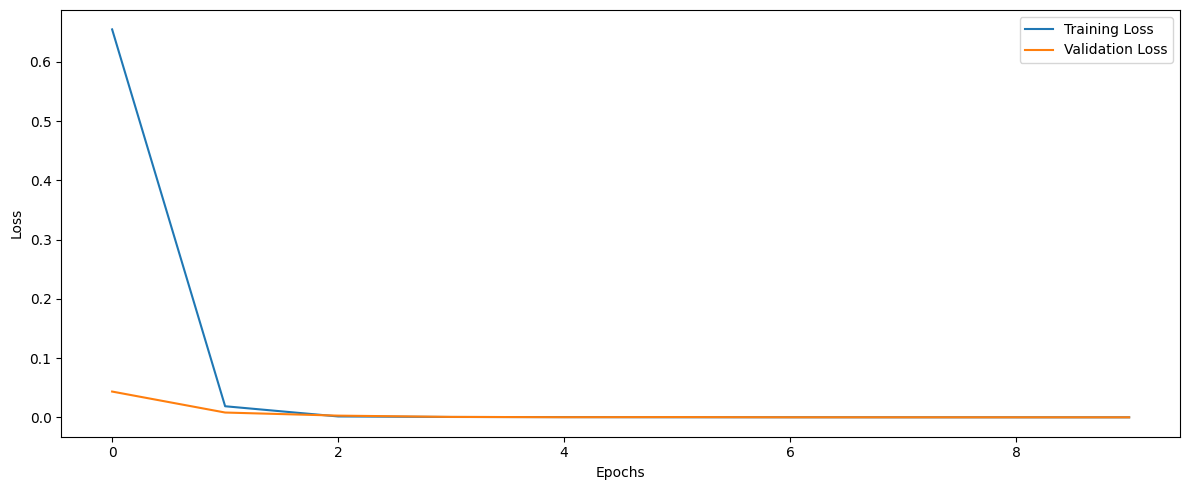

In [18]:
import matplotlib.pyplot as plt

print("Keys in history:", history.history.keys())

plt.figure(figsize=(12, 5))
plt.plot(history.history['train_loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()


plt.tight_layout()
plt.show()

# 4. EVALUATION


The function "autoregressive_decode" is created. This function is called by the test function to perform the evaluation of the model.

In [9]:
def autoregressive_decode(model, encoder_input):
    # add batch dimension for the model
    encoder_input = tf.constant([encoder_input])
    generated = model.generate_vec(encoder_input)

    # Remove sos token
    return generated[0][1:]
    #[0] removes(select) the batch dimension
    #[1:] remove SOS

We shall evaluate a generated item y_pred using "prefix accuracy", the lenght of the initial prefix of y_pred matching the ground true y_true. This will be divided by the maximum length of y_true and y_pred (up to EOS), so that a perfect match has score 1.

In [10]:
def prefix_accuracy_single(y_true, y_pred, id_to_token_map):

    t_str = decode_sequence(y_true, id_to_token_map)
    p_str = decode_sequence(y_pred, id_to_token_map)
    t_tokens = list(t_str)
    p_tokens = list(p_str)

    max_len = max(len(t_tokens), len(p_tokens))
    if max_len == 0:
        return 1.0  # both are empty

    match_len = sum(1 for x, y in zip(t_tokens, p_tokens) if x == y)
    score = match_len / max_len
    return score


def test(model, no=20, rounds=10):

    round_scores = []
    print("\n Performing Final Evaluation...")
    for i in range(rounds):
        X_test, Y_test = generate_dataset(no)
        scores = []
        for j in range(no):
            encoder_input = X_test[j]
            generated_tokens = autoregressive_decode(model, encoder_input)
            scores.append(prefix_accuracy_single(Y_test[j], generated_tokens, id_to_token))
        mean_round_score = np.mean(scores)
        round_scores.append(mean_round_score)
        print(f"Round {i+1}/{rounds} | Average Prefix Accuracy: {mean_round_score:.4f}")

    final_mean = np.mean(round_scores)
    final_std = np.std(round_scores)
    return final_mean, final_std

# Final test
mean_score, std_dev = test(model, no=20, rounds=10)
print("\n Completed")
print(f"Final Score (Mean over {10} rounds): {mean_score:.4f}")
print(f"Standard Deviation: {std_dev:.4f}")



 Performing Final Evaluation...
Round 1/10 | Average Prefix Accuracy: 1.0000
Round 2/10 | Average Prefix Accuracy: 1.0000
Round 3/10 | Average Prefix Accuracy: 1.0000
Round 4/10 | Average Prefix Accuracy: 1.0000
Round 5/10 | Average Prefix Accuracy: 1.0000
Round 6/10 | Average Prefix Accuracy: 1.0000
Round 7/10 | Average Prefix Accuracy: 1.0000
Round 8/10 | Average Prefix Accuracy: 1.0000
Round 9/10 | Average Prefix Accuracy: 1.0000
Round 10/10 | Average Prefix Accuracy: 1.0000

 Completed
Final Score (Mean over 10 rounds): 1.0000
Standard Deviation: 0.0000
